# ASH Strategy Research - Round 2

In [2]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({'figure.figsize': (14, 5), 'figure.dpi': 120})

In [48]:
# config
DATA_DIR = "../data"
DAY_LEN = 1_000_000

# prices data
prices = pd.concat(
    [pd.read_csv(f, sep=";") for f in sorted(glob.glob(f"{DATA_DIR}/prices_round_2_day_*.csv"))],
    ignore_index=True,
).sort_values(["day", "timestamp"]).reset_index(drop=True)

# trades data
trades = pd.concat(
    [pd.read_csv(f, sep=";").assign(day=int(f.split("day_")[1].split(".")[0]))
     for f in sorted(glob.glob(f"{DATA_DIR}/trades_round_2_day_*.csv"))],
    ignore_index=True,
).sort_values(["day", "timestamp"]).reset_index(drop=True)

# continuous time index 
prices["time"] = (prices["day"] - prices["day"].min()) * DAY_LEN + prices["timestamp"]
trades["time"] = (trades["day"] - trades["day"].min()) * DAY_LEN + trades["timestamp"]

# mid price and spread
prices["mid_price"] = (prices["bid_price_1"] + prices["ask_price_1"]) / 2
prices["spread"] = prices["ask_price_1"] - prices["bid_price_1"]

# ash data
ash_prices = prices[prices["product"] == "ASH_COATED_OSMIUM"].reset_index(drop=True)
ash_trades = trades[trades["symbol"] == "ASH_COATED_OSMIUM"].reset_index(drop=True)

# merge data (prices + trades)
ash_trades_wide = ash_trades.assign(i=ash_trades.groupby("time").cumcount() + 1).pivot(index="time", columns="i", values=["price", "quantity"])
ash_trades_wide.columns = [f"trade_{name}_{i}" for name, i in ash_trades_wide.columns]
ash_trades_wide = ash_trades_wide.reset_index()
ash = ash_prices.merge(ash_trades_wide, on="time", how="left")

# trade side (buy or sell)
ash["trade_side_1"] = np.where(ash["trade_price_1"] == ash["bid_price_1"], "sell", "buy")
ash["trade_side_2"] = np.where(ash["trade_price_2"] == ash["bid_price_1"], "sell", "buy")

# bid/ask level counts
ash["bid_level_count"] = ash[["bid_price_1", "bid_price_2", "bid_price_3"]].notna().sum(axis=1)
ash["ask_level_count"] = ash[["ask_price_1", "ask_price_2", "ask_price_3"]].notna().sum(axis=1)

# deepest bid/ask volume
ash["deepest_bid_volume"] = ash[["bid_volume_1", "bid_volume_2", "bid_volume_3"]].ffill(axis=1).iloc[:, -1]
ash["deepest_ask_volume"] = ash[["ask_volume_1", "ask_volume_2", "ask_volume_3"]].ffill(axis=1).iloc[:, -1]

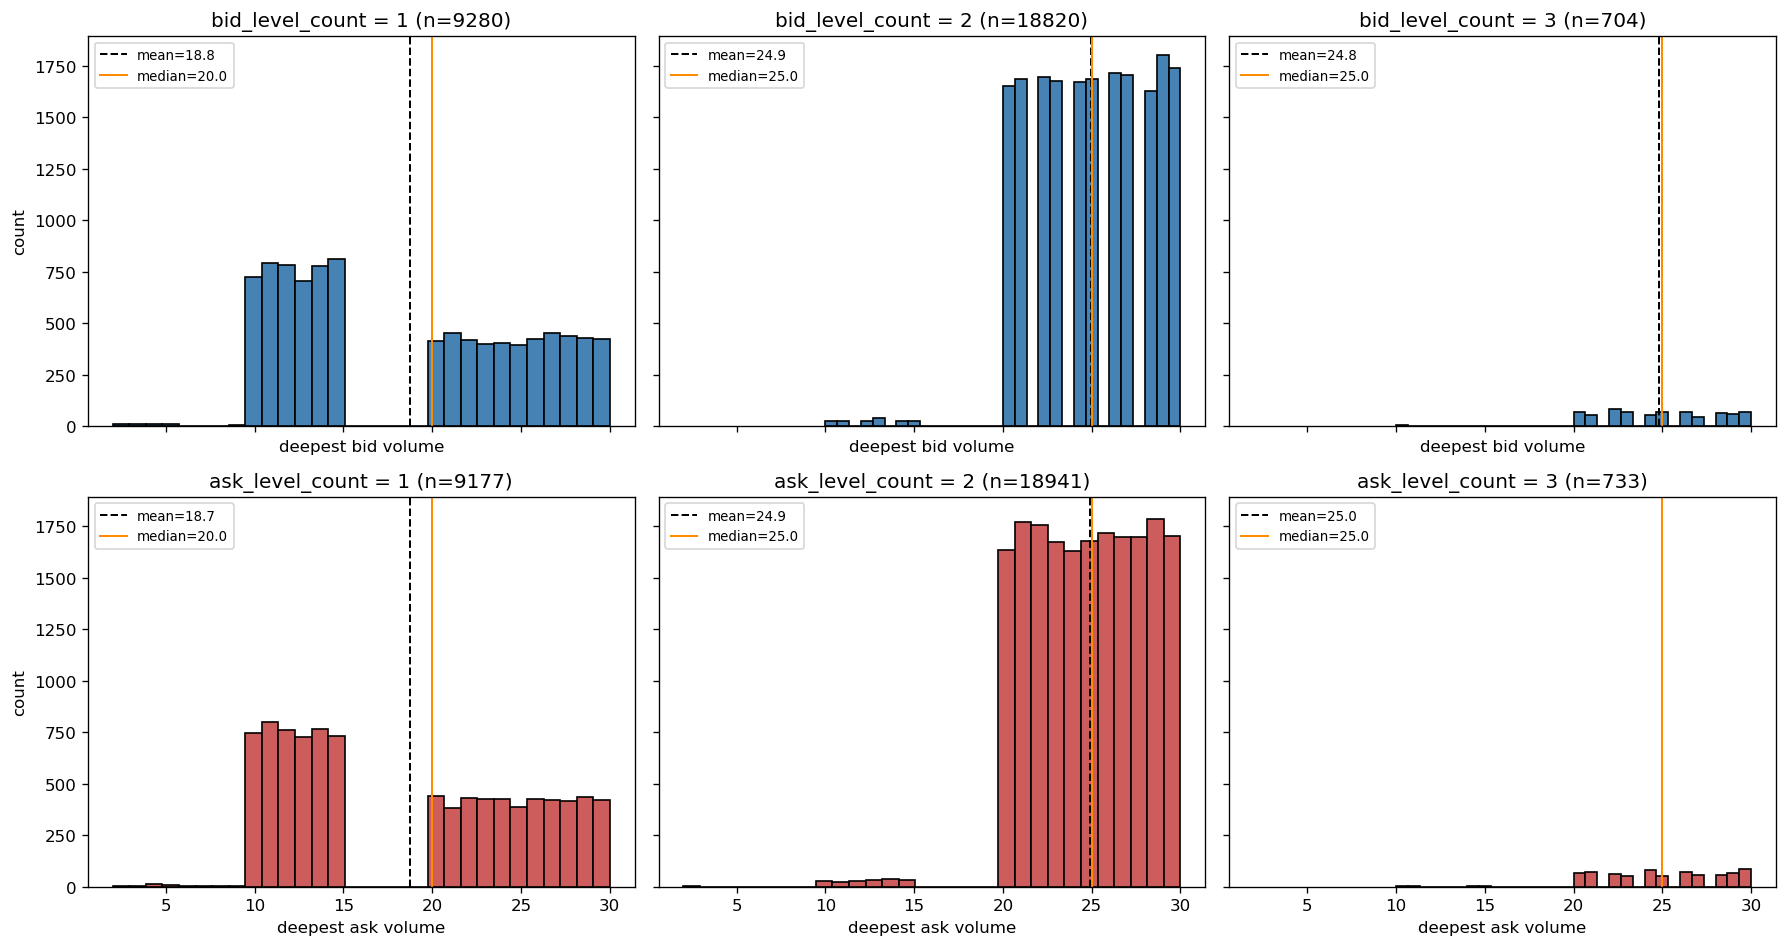

In [70]:
# deepest volume distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

def plot_hist(ax, vals, color, title, xlabel):
    ax.hist(vals, bins=30, color=color, edgecolor="black")
    m, med = vals.mean(), vals.median()
    ax.axvline(m, color="black", linestyle="--", linewidth=1.2, label=f"mean={m:.1f}")
    ax.axvline(med, color="darkorange", linestyle="-", linewidth=1.2, label=f"median={med:.1f}")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend(loc="upper left", fontsize=8)

for j, c in enumerate([1, 2, 3]):
    bid_vals = ash.loc[ash["bid_level_count"] == c, "deepest_bid_volume"].dropna()
    plot_hist(axes[0, j], bid_vals, "steelblue",
              f"bid_level_count = {c} (n={len(bid_vals)})", "deepest bid volume")

    ask_vals = ash.loc[ash["ask_level_count"] == c, "deepest_ask_volume"].dropna()
    plot_hist(axes[1, j], ask_vals, "indianred",
              f"ask_level_count = {c} (n={len(ask_vals)})", "deepest ask volume")

axes[0, 0].set_ylabel("count")
axes[1, 0].set_ylabel("count")
plt.tight_layout(); plt.show()

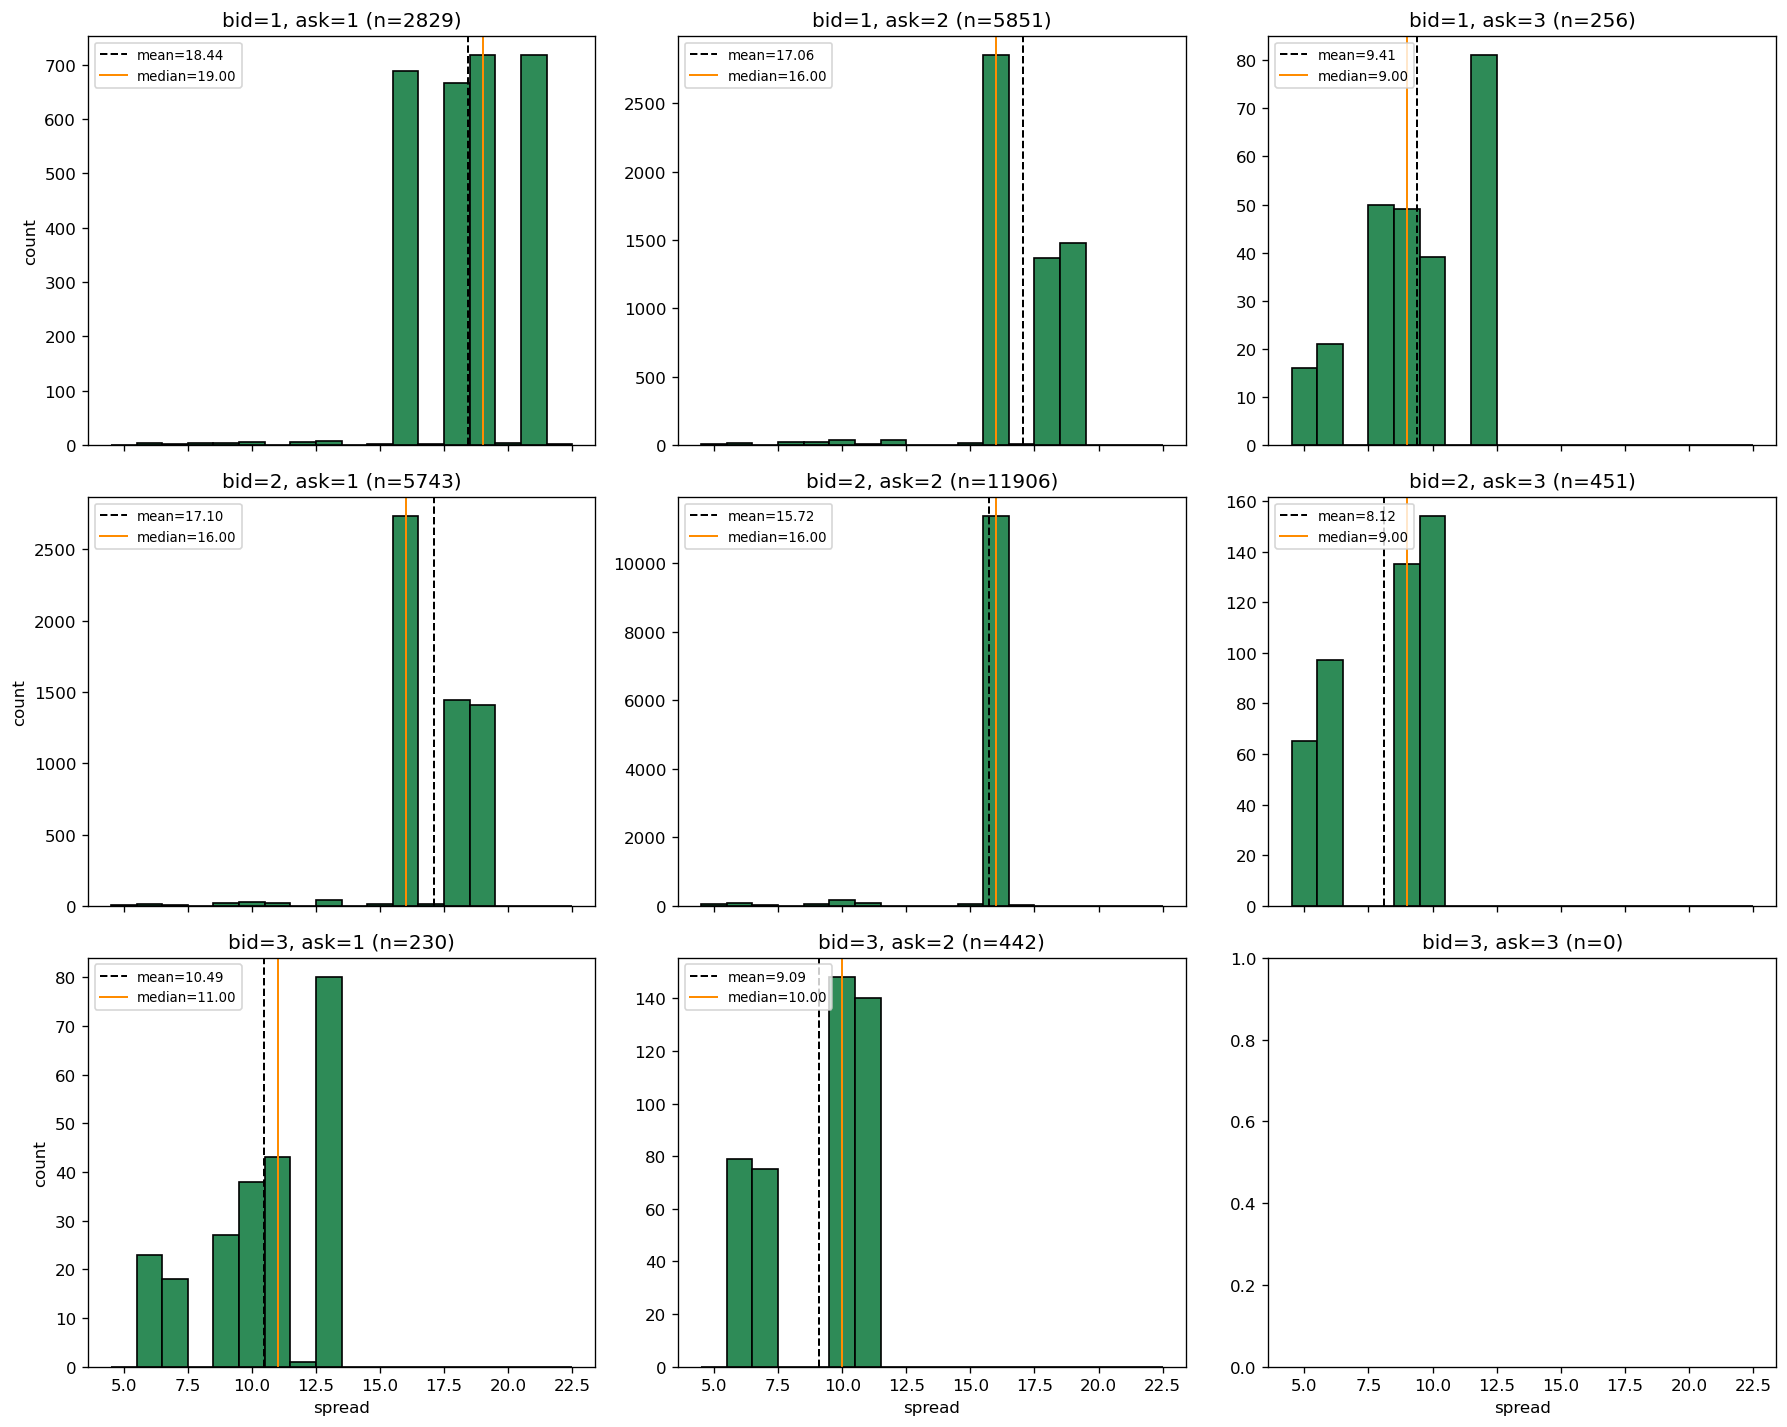

In [73]:
# spread distribution
spread_all = ash["spread"].dropna()
bins = np.arange(spread_all.min() - 0.5, spread_all.max() + 1.5, 1)

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True)
for i, bc in enumerate([1, 2, 3]):
    for j, ac in enumerate([1, 2, 3]):
        ax = axes[i, j]
        vals = ash.loc[(ash["bid_level_count"] == bc) & (ash["ask_level_count"] == ac), "spread"].dropna()
        if len(vals):
            ax.hist(vals, bins=bins, color="seagreen", edgecolor="black")
            ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1.2, label=f"mean={vals.mean():.2f}")
            ax.axvline(vals.median(), color="darkorange", linestyle="-", linewidth=1.2, label=f"median={vals.median():.2f}")
            ax.legend(loc="upper left", fontsize=8)
        ax.set_title(f"bid={bc}, ask={ac} (n={len(vals)})")
        if i == 2: ax.set_xlabel("spread")
        if j == 0: ax.set_ylabel("count")
plt.tight_layout(); plt.show()

In [106]:
# wall mid price
def wall_price(row, side, min_volume):  # side = "bid" or "ask"
    for lvl in [3, 2, 1]:   # deepest first
        p, v = row.get(f"{side}_price_{lvl}"), row.get(f"{side}_volume_{lvl}")
        if pd.notna(p) and pd.notna(v) and v >= min_volume:
            return p
    return np.nan

WALL_MIN_VOLUME = 20
ash["wall_bid"] = ash.apply(lambda r: wall_price(r, "bid", WALL_MIN_VOLUME), axis=1)
ash["wall_ask"] = ash.apply(lambda r: wall_price(r, "ask", WALL_MIN_VOLUME), axis=1)
ash["wall_mid"] = (ash["wall_bid"] + ash["wall_ask"]) / 2

# consecutive-NaN distribution
is_nan = ash["wall_mid"].isna()
group_id = (~is_nan).cumsum()                 # new id each time a non-NaN appears
run_lengths = is_nan.groupby(group_id).sum()  # count NaNs per group
run_lengths = run_lengths[run_lengths > 0]    # keep only actual NaN runs
print(run_lengths.describe())

# ffill NaN wall mids
ash["wall_mid"] = ash["wall_mid"].ffill()

count    6984.000000
mean        1.534651
std         0.896603
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         9.000000
Name: wall_mid, dtype: float64


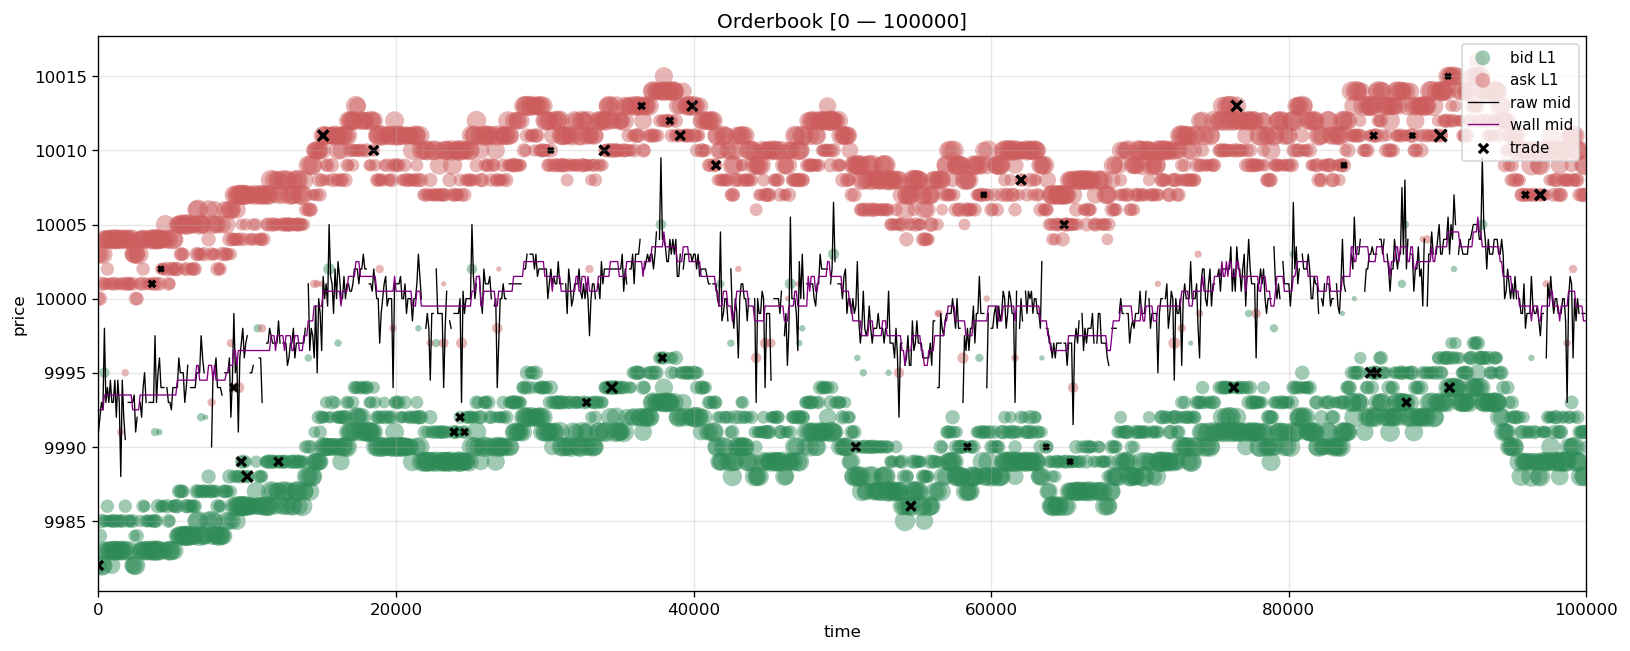

In [109]:
# orderbook and trades
def plot_orderbook(df, t_start, t_end, ax=None, show_trades=True):
    """
    Visualize the orderbook over [t_start, t_end].
    Each bid/ask level is plotted as a scatter where marker size is the resting volume.
    The mid price is overlaid as a line and executed trades are shown as X markers.
    """
    sub = df[(df["time"] >= t_start) & (df["time"] <= t_end)]
    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 6))

    for lvl in [1, 2, 3]:
        b = sub.dropna(subset=[f"bid_price_{lvl}"])
        a = sub.dropna(subset=[f"ask_price_{lvl}"])
        ax.scatter(b["time"], b[f"bid_price_{lvl}"], s=b[f"bid_volume_{lvl}"] * 5,
                   color="seagreen", alpha=0.45, edgecolor="none",
                   label=f"bid L{lvl}" if lvl == 1 else None)
        ax.scatter(a["time"], a[f"ask_price_{lvl}"], s=a[f"ask_volume_{lvl}"] * 5,
                   color="indianred", alpha=0.45, edgecolor="none",
                   label=f"ask L{lvl}" if lvl == 1 else None)

    ax.plot(sub["time"], sub["mid_price"], color="black", linewidth=0.8, label="raw mid")
    ax.plot(sub["time"], sub["wall_mid"], color="purple", linewidth=0.8, label="wall mid")

    if show_trades:
        for i in [1, 2]:
            tcol, qcol = f"trade_price_{i}", f"trade_quantity_{i}"
            if tcol in sub.columns:
                t = sub.dropna(subset=[tcol])
                ax.scatter(t["time"], t[tcol], s=t[qcol] * 5, marker="x",
                           color="black", linewidth=2,
                           label="trade" if i == 1 else None)

    ax.set_xlim(t_start, t_end)
    ax.set_xlabel("time"); ax.set_ylabel("price")
    ax.set_title(f"Orderbook [{t_start} — {t_end}]")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)
    return ax

plot_orderbook(ash, 0, 100_000)
plt.show()